# Imports

In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc

from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from models.trainer_ESN_LBFGS import fit_ESN_MMD_LBFGS

from loss.loss import compute_mmd_loss

from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv
from utils.analyse_controlled_experiments import *
from utils.analyse_results import *
from utils.data import *

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

In [2]:
torch.manual_seed(2)
np.random.seed(2)

# Generators

Initialize ESN and target parameters.

- note: now I am using target rho to scale C too! this way i can control the magnitude of the "states" pre activation

In [3]:
T = 100 # length of time series
N = 100  # number of samples (for target)
N_esn = 2000

xi_ma_theta = None 
d = 1   # dimension of time series
W_init_std = 0.1 # standard deviation for initializing the ESN output weight matrix W
noise = Noise("normal")

target_type = "returns" # choice of target type: "returns", "log_returns", "sqrd_log_returns"

In [4]:
h, m, d = 500, 20, 1 # ESN hyperparameters: reservoir size, input dimension (\xi : randomness), output dimension
activation = "none"
quad_feedback = False # whether to include quadratic feedback in the ESN reservoir (to capture some nonlinearity and volatility clustering)
quad_gain = 0.0 # if set to 0.0 then no quadratic feedback
xi_scale = 1.0
eta_scale = 0.05

target_rho = 0.7 # spectral radius for the ESN reservoir (matrix A))
C_scale = 0.5 # scaling factor for the ESN input weight matrix C (which controls how strongly the input \xi drives the reservoir dynamics)

washout_len = h

A = torch.randn(h, h) / (h ** 0.5) # ESN reservoir weight matrix
C = C_scale * target_rho * torch.randn(h, m) / (m ** 0.5) # ESN input weight matrix

Create trainable ESN and target ESN instances.

In [5]:
p = 1   # AR order
q = 1   # MA order
phi = [0.7] # AR coefficients
theta = [0.2] # MA coefficients
burnin = 50 # number of initial samples to discard to mitigate initialization effects

target_generator = ARMA(T=T, p=p, q=q, phi=phi, theta=theta, d=d, burnin=burnin, noise=noise)

In [6]:
# ESN estimator
esn = ESNGenerator(A, C, out_dim=d, xi_scale=xi_scale, 
                   eta_scale=eta_scale, activation=activation, 
                   target_rho=target_rho, xi_ma_theta=xi_ma_theta, 
                   quad_feedback=quad_feedback, quad_gain=quad_gain,
                   W_init=None, washout_len=washout_len) # if random W
                #  W_init=W_fixed) # if want to start from correct W

# Kernels

In [7]:
with torch.no_grad():
    Z_target_raw = target_generator.generate(T=T, N=N).to(device=device, dtype=dtype)
    Z_esn_raw = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

# Apply the selected target transformation
eps = 1e-8

if target_type == "returns":
    Z_target = Z_target_raw
    Z_esn = Z_esn_raw
elif target_type == "log_returns":
    Z_target = torch.log1p(Z_target_raw)
    Z_esn = torch.log1p(Z_esn_raw)
elif target_type == "sqrd_log_returns":
    log_r = torch.log1p(Z_target_raw)
    Z_target = log_r ** 2
    Z_esn = torch.log1p(Z_esn_raw) ** 2
elif target_type == "log_sqrd_returns":
    Z_target = torch.log(Z_target_raw ** 2 + eps)
    Z_esn = torch.log(Z_esn_raw ** 2 + eps)

print(f"Generated data shapes: Z_target: {Z_target.shape}, Z_esn: {Z_esn.shape}")
_median_heuristic_sigma = median_heuristic_sigma(Z_target, Z_esn)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Generated data shapes: Z_target: torch.Size([100, 100, 1]), Z_esn: torch.Size([2000, 100, 1])
Median heuristic sigma: 15.749454


In [8]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**{'static_kernel_type': static_kernel_type, 'n_levels': n_levels, 'kernel_sigma': disc_sig_kernel_sigma})

#---------------------------------
# Define the pde signature kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# # Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

## Choose kernel

Choose one kernel

In [9]:
# kernel = sig_disc_kernel      # discretized signature kernel
# kernel = sig_pde_kernel        # pde signature kernel
kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel      # volterra kernel

Run initial MMD to check and as a baseline

In [10]:
if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")

# initial mmd:
initial_mmd = compute_mmd_loss(kernel, Z_target, Z_esn) if kernel_mode == "sequential" else compute_mmd_loss(kernel, Z_target.reshape(Z_target.shape[0], -1), Z_esn.reshape(Z_esn.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

Using kernel: RBFKernel with kernel mode: static
Initial MMD with RBFKernel kernel: 0.064647


# Baseline MMD

In [11]:
# iterations = 1000
# N_small = N
# N_large = N_esn
# baseline_mmd = compute_baseline_mmd(target_generator,kernel,noise,iterations,N_small,N_large,kernel_mode,dtype,device, target_type)
# print("Baseline MMD:", baseline_mmd)

# Statistical Analysis Before Fitting

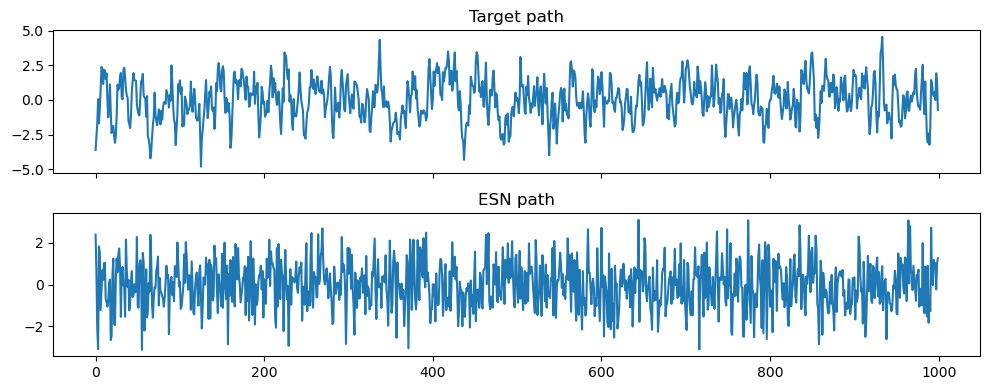

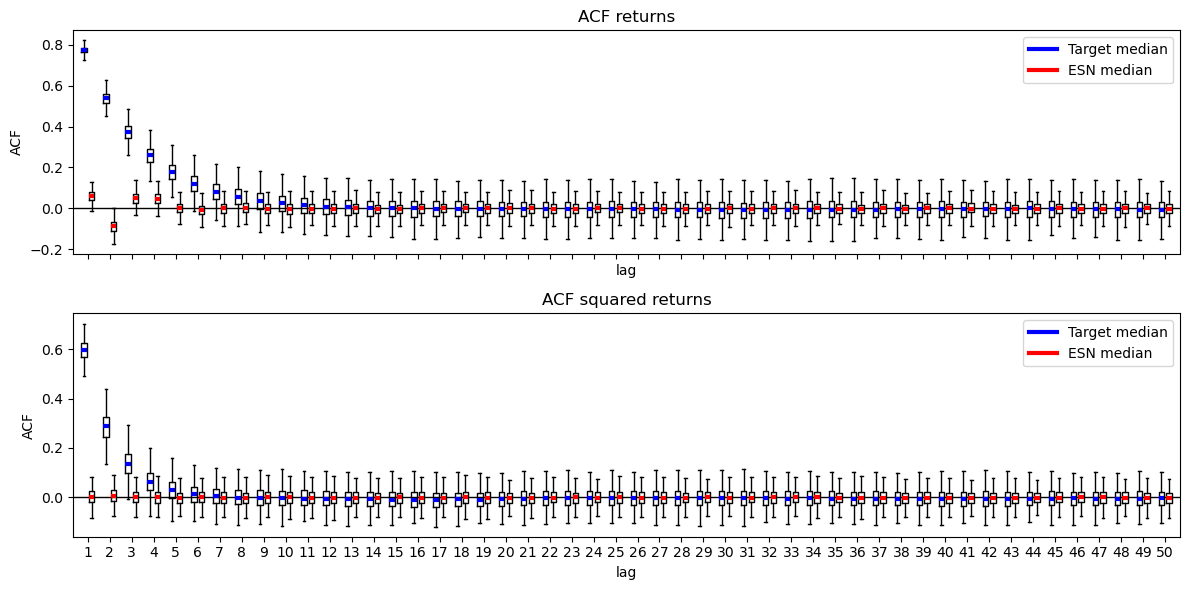

In [12]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [13]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")



ACF two-sample test summary
ACF(joint) -> T_obs: 66.777488, p_value: 0.000000
ACF(x^2)   -> T_obs: 20.581673, p_value: 0.000000
ACF(x)     -> T_obs: 46.195814, p_value: 0.000000


# Fit ESN

In [14]:
print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
results = fit_ESN_MMD_LBFGS(esn = esn, 
                            Z_target = Z_target,
                            kernel = kernel, 
                            kernel_mode = kernel_mode,
                            N_model= N_esn, 
                            lead_lag=False,
                            lags=0,
                            max_iter = 1000, 
                            lr=0.1, 
                            force_float64=True,
                            verbose=True,
                            target_type=target_type
)


Using kernel: RBFKernel with kernel mode: static
MMD initial: 0.06748711184093091
Eval 100: Loss 0.001359
Eval 200: Loss 0.001358
MMD final: 0.0013580643530185488


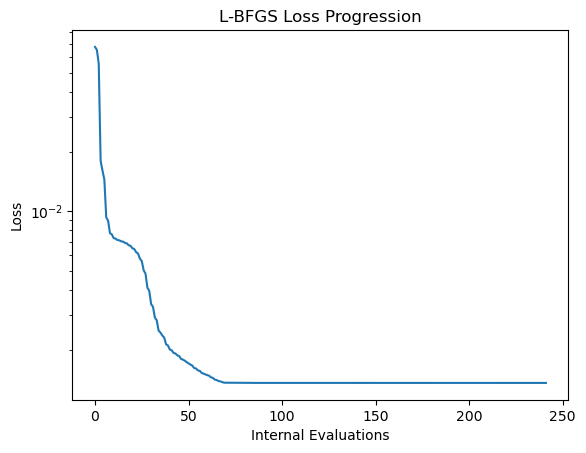

In [15]:
loss_history = results['loss_history']
plt.plot(loss_history)
plt.xlabel('Internal Evaluations')
plt.ylabel('Loss')
plt.title('L-BFGS Loss Progression')
plt.yscale('log') # Useful if loss drops several orders of magnitude
plt.show()

# Statistical Analysis After Fitting

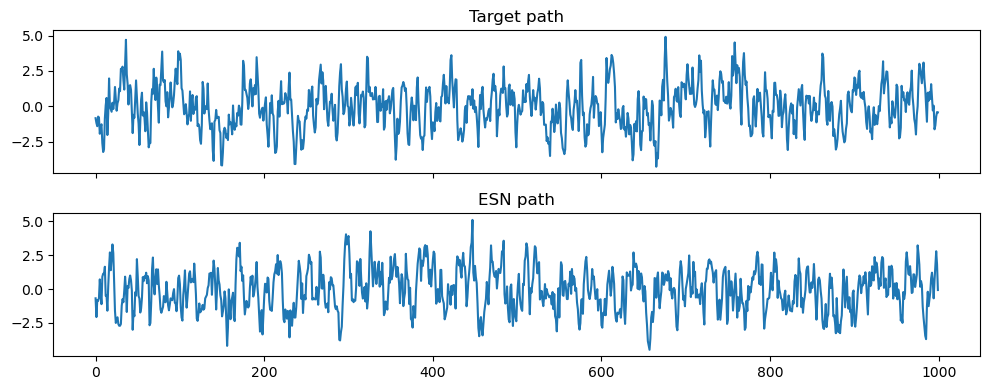

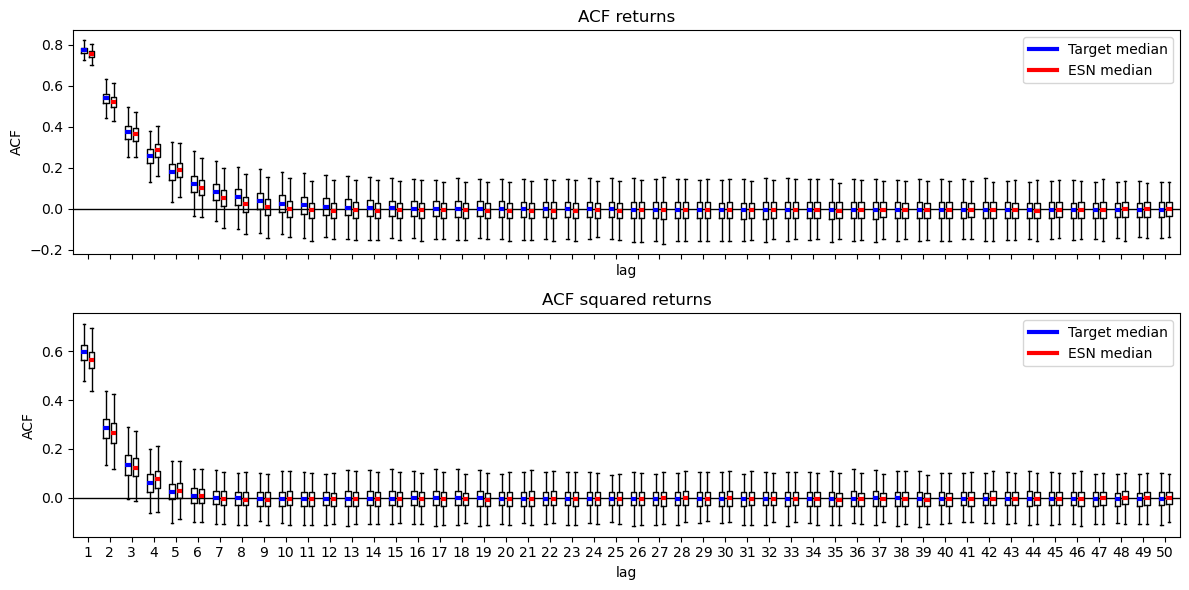

In [16]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [17]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")



ACF two-sample test summary
ACF(x)     -> T_obs: 1.018159, p_value: 0.413000
ACF(x^2)   -> T_obs: 1.003282, p_value: 0.451000
ACF(joint) -> T_obs: 2.021440, p_value: 0.449000


In [18]:
# target
phis_tgt, thetas_tgt = fit_arma_on_paths(Z_target[...,0], p=1, q=1)

# esn
with torch.no_grad():
    Z_esn = esn(T=T_acf, N=N_acf).cpu().numpy()

phis_esn, thetas_esn = fit_arma_on_paths(Z_esn[...,0], p=1, q=1)

# compare
print("target:", summarize_params(phis_tgt, thetas_tgt))
print("esn:", summarize_params(phis_esn, thetas_esn))

target: {'phi_mean': array([0.68370703]), 'phi_std': array([0.08462067]), 'phi_median': array([0.7006094]), 'theta_mean': array([0.22545738]), 'theta_std': array([0.12384627]), 'theta_median': array([0.22360068])}
esn: {'phi_mean': array([0.69593284]), 'phi_std': array([0.02947606]), 'phi_median': array([0.69654068]), 'theta_mean': array([0.14040891]), 'theta_std': array([0.04033189]), 'theta_median': array([0.14025365])}


# Check states with the current activation to see saturation levels

In [19]:
Z, X, pre_activation = esn.forward(T=200, return_states=True, track_saturation=True)
print("activation type:", activation)

activation type: none


In [20]:
# pre: (N, T, h)
pre_act = pre_activation.detach()

# boolean mask
mask_1 = (pre_act.abs() > 1.0).float()
mask_2 = (pre_act.abs() > 2.0).float()

# percentage per dimension (average over N and T)
perc_per_dim_1 = mask_1.mean(dim=(0, 1))   # shape (h,)

# percentage |z|>2 per dimension
perc_per_dim_2 = mask_2.mean(dim=(0, 1))   # shape (h,)

# mean over dimensions
mean_perc_1 = perc_per_dim_1.mean().item()
mean_perc_2 = perc_per_dim_2.mean().item()

print("mean percentage |z|>1 across dims:", mean_perc_1)
print("mean percentage |z|>2 across dims:", mean_perc_2)
print("percentage |z|>1 per dim (first 3 dim):", perc_per_dim_1[:3].cpu().numpy())
print("percentage |z|>2 per dim (first 3 dim):", perc_per_dim_2[:3].cpu().numpy())

mean percentage |z|>1 across dims: 0.03732999786734581
mean percentage |z|>2 across dims: 9.999999747378752e-05
percentage |z|>1 per dim (first 3 dim): [0.01  0.075 0.02 ]
percentage |z|>2 per dim (first 3 dim): [0. 0. 0.]


In [21]:
import torch
import plotly.graph_objects as go

pa = pre_activation.detach().cpu()

if pa.dim() == 3:
    pa = pa[0]   # (T, h)

T, h = pa.shape

# x coordinates:
# repeat each timestep h times
x = torch.arange(T).repeat_interleave(h)

# y coordinates:
# flatten all activations
y = pa.reshape(-1)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="markers",
        marker=dict(
            size=3,
            opacity=0.25
        )
    )
)

fig.update_layout(
    title="Pre-activation distribution over time",
    xaxis_title="t",
    yaxis_title="z",
    showlegend=False
)

fig.show()

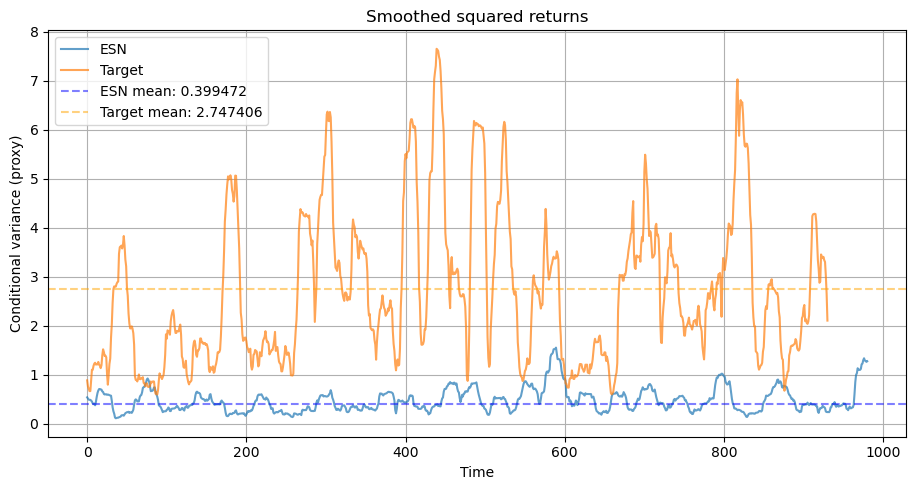

ESN mean: 0.399472, var: 0.184574
Target mean: 2.747406, var: 17.345942


In [22]:
eps = torch.randn(1, 1500, 1, device=device, dtype=dtype)

v = torch.randn(esn.m, device=device, dtype=dtype)
v = v / (v.norm() + 1e-8)
_eps = eps * v.view(1, 1, esn.m) # first coupling
rho = 0.9 # pick rho = to 1 to have same innovations
eta = torch.randn(1, 1500, esn.m, device=device, dtype=dtype)
eps_for_esn = (
    rho * _eps
    + (1 - rho**2) ** 0.5 * eta
)

eps_for_target = eps.clone()[:,500:,:]  # ensure same noise for both ESN and target for the first 1000 steps

with torch.no_grad():
    Z_esn_for_cond_var = esn(T=1000, N=1, xi=eps_for_esn).to(device=device, dtype=dtype)
    Z_target_for_cond_var = target_generator.generate(T=1000, N=1, eps=eps_for_target).to(device=device, dtype=dtype)

window = 20

# =========================
# squared returns (proxy for conditional variance)
# =========================
Z_esn_sq = Z_esn_for_cond_var ** 2
Z_target_sq = Z_target_for_cond_var ** 2

# =========================
# rolling mean of squared returns
# =========================
esn_windows = Z_esn_sq.unfold(dimension=1, size=window, step=1)
target_windows = Z_target_sq.unfold(dimension=1, size=window, step=1)

conditional_var = esn_windows.mean(dim=-1)
target_conditional_var = target_windows.mean(dim=-1)

# =========================
# plot
# =========================
plt.figure(figsize=(18, 5))


step = window

esn_sample = Z_esn_sq[:, ::step]
target_sample = Z_target_sq[:, ::step]

esn_flat = esn_sample.detach().cpu().numpy().flatten()
target_flat = target_sample.detach().cpu().numpy().flatten()

plt.subplot(1, 2, 2)
plt.plot(conditional_var.mean(0).cpu().numpy(), label='ESN', alpha=0.7)
plt.plot(target_conditional_var.mean(0).cpu().numpy(), label='Target', alpha=0.7)
plt.axhline(y=esn_flat.mean(), color='blue', linestyle='--', alpha=0.5, label=f'ESN mean: {esn_flat.mean():.6f}')
plt.axhline(y=target_flat.mean(), color='orange', linestyle='--', alpha=0.5, label=f'Target mean: {target_flat.mean():.6f}')
plt.xlabel('Time')
plt.ylabel('Conditional variance (proxy)')
plt.title('Smoothed squared returns')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print(f"ESN mean: {esn_flat.mean():.6f}, var: {esn_flat.var():.6f}")
print(f"Target mean: {target_flat.mean():.6f}, var: {target_flat.var():.6f}")